# Русская гравийная серия как продукт: рост, удержание и точки роста

**Автор:** Царегородский Александр · **Данные:** открытый архив протоколов [gravelseries.ru](https://gravelseries.ru/results), 2018–2026

Русская гравийная серия (РГС) объединяет независимых организаторов гревел-гонок: у них общий рейтинг и общий календарь.
Я смотрю на серию **как на продукт**: гонщик — пользователь, старт — сессия, сезон — период.

**Заказчик** — объединение организаторов серии. **Решение**, которое он принимает: куда вкладывать усилия между сезонами —
в привлечение новичков, в их удержание или в связку этапов между собой.

Продуктовые вопросы:

1. **Рост.** Как растёт аудитория и за счёт чего: новички или вернувшиеся?
2. **Удержание.** Сколько новичков возвращается на следующий сезон? Как это менялось?
3. **Aha-момент.** Что в первом сезоне отличает тех, кто вернулся?
4. **Точки входа.** После каких этапов новички возвращаются чаще?
5. **Экосистема.** Как пересекаются аудитории этапов?
6. **Прогрессия.** Переходят ли гонщики с коротких дистанций на длинные?
7. **Аудитория и трассы.** Доля женщин, сходы, скорость.
8. **Проверка.** Как подтвердить главный вывод экспериментом.

> Пайплайн: `extract` (API сайта) → `transform` (очистка, сведение гонщиков) → `load` (DuckDB + SQL-витрины) → этот ноутбук.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.formula.api as smf

from gravel import viz
from gravel.load import connect
from gravel.viz import BLUE, ORANGE, AQUA, YELLOW, GRAY, TEXT, TEXT_2, TEXT_3, SURFACE

viz.setup()
pd.set_option("display.max_columns", 30)
con = connect()
q = lambda sql: con.sql(sql).df()

## 1. Данные и их качество

Архив содержит все протоколы этапов серии и её предшественников («Gravel King» 2018, «Обратная сторона» 2019–2021).
Сырые данные грязные, и большая часть работы ушла на очистку (`src/gravel/transform.py`):

| Проблема | Решение |
|---|---|
| Один человек записан по-разному: «ЦАРЕВ СЕРГЕЙ», «Сергей Царев», «Дима/Дмитрий», с отчеством и без, двойные фамилии | ключ = нормализованные токены (регистр, ё→е, без отчества, уменьшительные → полные имена), алиас для фамилии в скобках |
| 6 форматов времени (`4:15:39`, `03:28:43.32`, `5:03:49,55`, `-`, `?`) | единый парсер → секунды |
| Пустой статус в старых протоколах | с очками → финиш без времени, без очков → сход |
| Километраж указан не везде | парсим из названия; уровень «длинная / короткая» берём из `maxPoints` (1000 = главная дистанция) |
| Места считаются то в абсолюте, то по полу | перцентиль среди финишёров своего пола внутри гонки |

In [2]:
q('''
SELECT
    (SELECT COUNT(*) FROM dim_event)                         AS events,
    (SELECT COUNT(*) FROM dim_race)                          AS races,
    (SELECT COUNT(*) FROM fct_result)                        AS results,
    (SELECT COUNT(DISTINCT name_raw) FROM fct_result)        AS raw_names,
    (SELECT COUNT(*) FROM dim_rider)                         AS riders_after_resolution,
    (SELECT MIN(year) || '–' || MAX(year) FROM dim_event)    AS period
''')

,events,races,results,raw_names,riders_after_resolution,period
0,34,66,7682,5088,3684,2018–2026


**Проверка качества сведения.** В API рейтингов сайта у гонщиков есть собственные ID (сезоны 2024–2026, 2 450 гонщиков).
Сверяю с ними свои ключи:

In [3]:
import json
from pathlib import Path
from gravel.transform import name_keys

raw = Path("../data/raw")
site = pd.DataFrame(
    [(e["racer"]["id"], e["displayName"]) for y in (2024, 2025, 2026)
     for e in json.loads((raw / f"rankings_{y}.json").read_text())["entries"]],
    columns=["site_id", "name"]).drop_duplicates()
site["my_key"] = site["name"].map(lambda n: name_keys(n)[0])

missed = (site.groupby("site_id")["my_key"].nunique() > 1).sum()       # один человек -> у меня два ключа
merged = site.groupby("my_key")["site_id"].nunique()
merged = merged[merged > 1]
print(f"ID на сайте: {site.site_id.nunique()}")
print(f"Не склеил (один ID сайта -> несколько моих ключей): {missed}")
print(f"Склеил в один ключ несколько ID сайта: {len(merged)}")
site[site.my_key.isin(merged.index)].groupby("my_key")["name"].agg(" | ".join).head(12).to_frame()

ID на сайте: 2450
Не склеил (один ID сайта -> несколько моих ключей): 1
Склеил в один ключ несколько ID сайта: 29


,name
my_key,
александр климов,Климов Александр | Климов Саша
александр шаврин,Шаврин Саша | Шаврин Александр
александр шестаков,Шестаков Александр | Шестаков Саша
алексей голубев,Голубев Алексей Евгеньевич | Голубев Алексей Е...
алексей павлов,Павлов Алексей | Павлов Алёша | ПАВЛОВ Алексей
алексей романов,Романов Алексей | Романов Алексей · №788
баринова екатерина,Баринова Екатерина | Баринова Катя
баронас ромуальдас-игорь,Баронас Ромуальдас-Игорь Витаутович | Баронас ...
бегемотов вячеслав,Бегемотов Слава | Бегемотов Вячеслав | Слава Б...


Не склеился **один** человек из 2 450: у гонщицы сменилась фамилия, по имени такое не поймать.
29 случаев, где я объединил несколько ID сайта, — это в основном **дубли, которые пропустил сам сайт** («Саша/Александр», «Слава/Вячеслав»).
Около 8 — настоящие тёзки (сайт помечает их номером «· №286»). Это ~0.3% гонщиков, на агрегаты не влияет.

## 2. Рост: аудитория выросла в 12 раз, и растёт она за счёт удержания

In [4]:
season = q("SELECT * FROM mart_season")
season[["year", "n_events", "riders", "starts", "starts_per_rider", "new_riders",
        "retained_from_prev", "resurrected", "female_share", "multi_event_share"]]

,year,n_events,riders,starts,starts_per_rider,new_riders,retained_from_prev,resurrected,female_share,multi_event_share
0,2018,1,145,149.0,1.03,145.0,0.0,0.0,0.076,0.000
1,2019,1,191,192.0,1.01,136.0,55.0,0.0,0.084,0.000
2,2020,1,337,343.0,1.02,241.0,88.0,8.0,0.128,0.000
3,2021,1,508,513.0,1.01,318.0,167.0,23.0,0.154,0.000
4,2022,2,204,206.0,1.01,153.0,40.0,11.0,0.216,0.010
5,2023,6,468,538.0,1.15,336.0,67.0,65.0,0.184,0.124
6,2024,7,643,844.0,1.31,386.0,192.0,65.0,0.168,0.219
7,2025,7,1315,1927.0,1.47,854.0,357.0,104.0,0.186,0.278
8,2026,8,1814,2786.0,1.54,1010.0,691.0,113.0,0.193,0.314


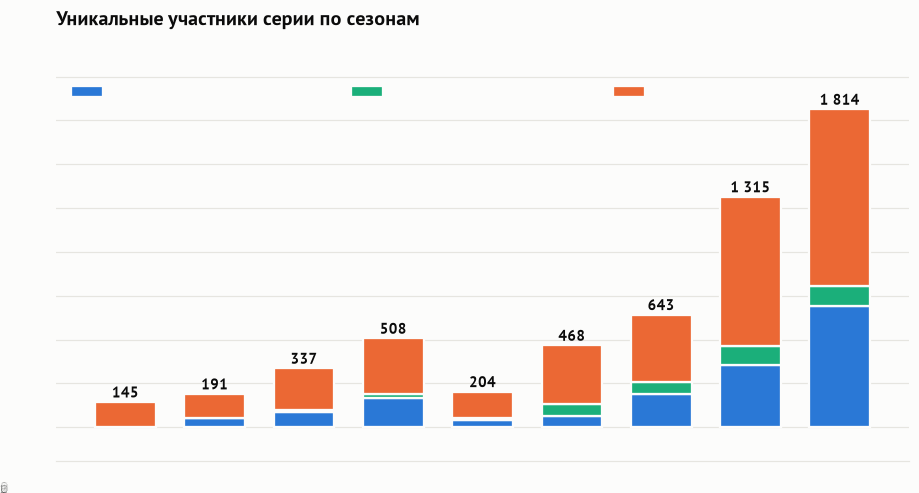

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.6))
s = season.set_index("year")
parts = [("retained_from_prev", "вернулись с прошлого сезона", BLUE),
         ("resurrected", "вернулись после перерыва", AQUA),
         ("new_riders", "новички", ORANGE)]
bottom = np.zeros(len(s))
for col, label, color in parts:
    ax.bar(s.index, s[col], bottom=bottom, color=color, width=0.68, label=label,
           edgecolor=SURFACE, linewidth=1.5)
    bottom += s[col].values
for x, total, ev in zip(s.index, s["riders"], s["n_events"]):
    ax.text(x, total + 25, f"{total:,}".replace(",", " "), ha="center", color=TEXT, fontsize=10, weight="bold")
    ax.text(x, -150, f"{ev} эт.", ha="center", color=TEXT_3, fontsize=8.5)
ax.set_ylim(-190, s["riders"].max() * 1.12)
ax.set_xticks(s.index)
ax.set_title("Уникальные участники серии по сезонам")
viz.subtitle(ax, "С 2023 года, когда сложилась серия из 6+ этапов, аудитория выросла в 3,9 раза")
ax.legend(loc="upper left", ncols=3, bbox_to_anchor=(0, 1.0))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", " ") if v >= 0 else ""))
viz.save(fig, "01_growth"); plt.show()

**Выводы:**
- В 2018 году был один старт на 145 человек, в 2026-м — 8 этапов, **1 814 уникальных гонщиков и 2 786 стартов**.
- Растёт не только число людей, но и **частота**: число стартов на гонщика выросло с 1,01 до 1,54. В 2026 году **31%** гонщиков проехали 2+ этапа (в 2023-м — 12%).
- Структура роста поменялась. В 2026 году впервые **больше трети аудитории (691 из 1 814) — вернувшиеся с прошлого сезона**. Серия перестаёт зависеть только от притока новичков.
- 2022 год — провал: всего 2 этапа (Спорт-Марафон Фест и SHULZ), 204 участника. Главная гревел-гонка страны, [«Обратная сторона дороги»](https://shchepinov.pro/reverse-race-5/) под Петербургом, прошла в последний раз в 2021-м, а общая серия ещё не сложилась.

## 3. Удержание: обвал 2022 года и восстановление до ~50%

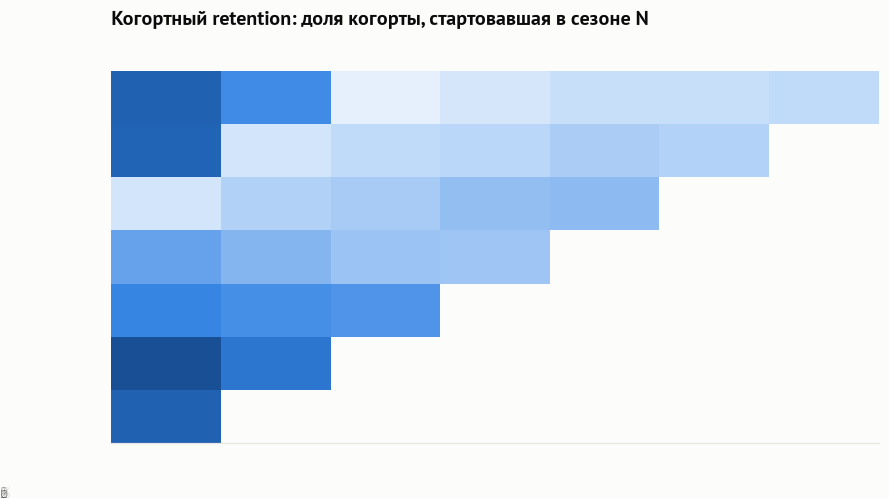

In [6]:
cohort = q("SELECT cohort, season_n, retention, riders FROM mart_cohort WHERE cohort BETWEEN 2019 AND 2025")
heat = cohort.pivot(index="cohort", columns="season_n", values="retention")
sizes = cohort[cohort.season_n == 0].set_index("cohort")["riders"]

fig, ax = plt.subplots(figsize=(9, 4.4))
data = heat.drop(columns=0)
im = ax.imshow(data.values, cmap=viz.BLUES, vmin=0, vmax=0.6, aspect="auto")
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=10,
                    color="white" if v > 0.33 else TEXT)
ax.set_xticks(range(data.shape[1]), [f"+{c}" for c in data.columns])
ax.set_yticks(range(data.shape[0]), [f"{c}  (n={sizes[c]})" for c in data.index])
ax.set_xlabel("сезонов после первого старта")
ax.grid(False)
ax.set_title("Когортный retention: доля когорты, стартовавшая в сезоне N")
viz.subtitle(ax, "Когорта = год первого старта. После провала 2022 года каждая новая когорта удерживается лучше предыдущей")
viz.save(fig, "02_cohorts"); plt.show()

**Выводы:**
- **Эпоха одной гонки (2019–2020):** retention +1 сезона ~45%. Небольшая лояльная аудитория ежегодно ездила одно событие, «Обратную сторону».
- **Обвал 2022 года:** «Обратная сторона» больше не проводилась, и у когорты 2021 года на следующий сезон вернулись лишь **7%**. Пользователей удерживало не «гревел вообще», а конкретное событие.
- **Восстановление серии:** с появлением общего календаря retention +1 вырос с 27% (когорта 2022) до 35% (2023) и **51% (2024)**, превзойдя уровень эпохи одной гонки, хотя когорты стали в 2–3 раза больше.
- Старые когорты «оживают»: у когорты 2021 года retention растёт со временем (7% → 20%). **Регулярность продукта сама по себе возвращает ушедших пользователей.**
- Небольшая просадка 2025 → 2026 (51% → 45%) объясняется размером когорты. Когорта 2025 года в 2,2 раза больше (854 новичка против 386), в ней больше «случайных» людей. Пока это не тревожный сигнал, но метрику стоит мониторить.

## 4. Aha-момент: вторая гонка в первом сезоне

Беру всех новичков 2022–2025 годов (n = 1 729) и смотрю, вернулись ли они в следующем сезоне.
Что в первом сезоне отличает вернувшихся?

In [7]:
newbies = q('''
WITH act AS (
    SELECT r.*, d.is_long FROM fct_result r JOIN dim_race d ON d.race_id = r.race_id
    WHERE r.status <> 'dns'
),
first AS (SELECT rider_id, MIN(year) AS fy FROM act GROUP BY 1),
fs AS (
    SELECT a.rider_id, f.fy,
           ANY_VALUE(a.gender)            AS gender,
           COUNT(*)                       AS starts,
           BOOL_OR(a.is_long)             AS any_long,
           MEDIAN(a.pct_rank)             AS med_pct,
           ARG_MIN(a.event_id, a.result_id) AS first_event
    FROM act a JOIN first f ON f.rider_id = a.rider_id AND a.year = f.fy
    GROUP BY 1, 2
),
ret AS (SELECT DISTINCT rider_id, year FROM act)
SELECT fs.*, (r.rider_id IS NOT NULL)::INT AS returned
FROM fs LEFT JOIN ret r ON r.rider_id = fs.rider_id AND r.year = fs.fy + 1
WHERE fy BETWEEN 2022 AND 2025
''')
newbies["starts_cat"] = newbies["starts"].clip(upper=3).map({1: "1", 2: "2", 3: "3+"})
newbies["pct_q"] = pd.cut(newbies["med_pct"], [-0.01, 0.25, 0.5, 0.75, 1.0],
                          labels=["топ-25%", "25–50%", "50–75%", "хвост"])
print(f"Новичков: {len(newbies)}, вернулись на следующий сезон: {newbies.returned.mean():.1%}")

Новичков: 1729, вернулись на следующий сезон: 43.0%


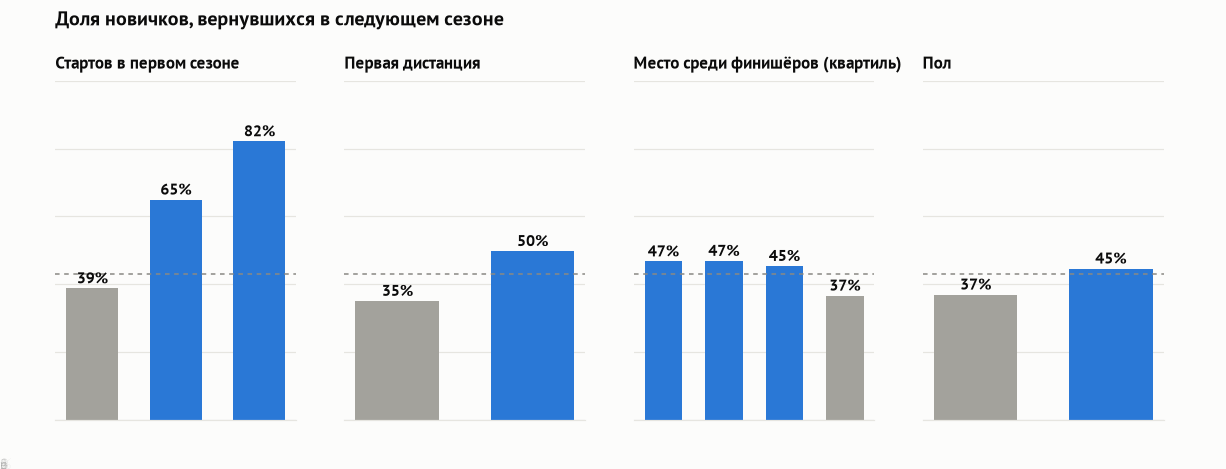

In [8]:
def rate(col, order=None):
    g = newbies.groupby(col, observed=True)["returned"].agg(["mean", "size"])
    return g.loc[order] if order else g

panels = [
    ("Стартов в первом сезоне", rate("starts_cat", ["1", "2", "3+"])),
    ("Первая дистанция", rate("any_long").rename(index={False: "только короткая", True: "длинная"})),
    ("Место среди финишёров (квартиль)", rate("pct_q")),
    ("Пол", rate("gender").rename(index={"F": "женщины", "M": "мужчины"})),
]
fig, axes = plt.subplots(1, 4, figsize=(13, 4), sharey=True)
base = newbies.returned.mean()
for ax, (title, g) in zip(axes, panels):
    colors = [BLUE if v >= base else GRAY for v in g["mean"]]
    ax.bar(range(len(g)), g["mean"], color=colors, width=0.62)
    ax.axhline(base, color=TEXT_3, lw=1, ls=(0, (3, 3)))
    for i, (v, n) in enumerate(zip(g["mean"], g["size"])):
        ax.text(i, v + 0.015, f"{v:.0%}", ha="center", weight="bold", fontsize=10.5)
    ax.set_xticks(range(len(g)), [f"{i}\nn={n}" for i, n in zip(g.index, g["size"])], fontsize=9)
    ax.set_title(title, fontsize=11, pad=8)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
axes[0].set_ylim(0, 1)
axes[-1].text(1.02, base, f"среднее\n{base:.0%}", transform=axes[-1].get_yaxis_transform(),
              color=TEXT_3, fontsize=8.5, va="center")
fig.suptitle("Доля новичков, вернувшихся в следующем сезоне", x=0.125, ha="left",
             fontsize=13, weight="bold", y=1.04)
viz.save(fig, "03_aha_moment"); plt.show()

Вторая гонка в первом сезоне поднимает возврат с 39% до 65%, третья и далее — до 82%.
Но это корреляция: те, кто сразу проехал две гонки, могут быть просто более мотивированными.
Проверяю, держатся ли эффекты вместе, в логистической регрессии. Две спецификации:
1. фиксированный эффект года — убирает общий тренд роста серии;
2. плюс фиксированный эффект первого этапа — альтернативное объяснение «дело не в числе стартов, а в том, на какой этап человек попал».

In [9]:
newbies["multi_start"] = (newbies.starts >= 2).astype(int)
newbies["female"] = (newbies.gender == "F").astype(int)
newbies["bottom_q"] = (newbies.med_pct > 0.75).astype(int)
newbies["long"] = newbies.any_long.astype(int)

newbies = newbies.merge(q("SELECT event_id, series_key FROM dim_event"), left_on="first_event", right_on="event_id")
d = newbies.dropna(subset=["med_pct"])
specs = {
    "1: год": "returned ~ multi_start + long + bottom_q + female + C(fy)",
    "2: год + первый этап": "returned ~ multi_start + long + bottom_q + female + C(fy) + C(series_key)",
}
rows = []
for name, f in specs.items():
    m = smf.logit(f, data=d).fit(disp=0)
    ci = np.exp(m.conf_int())
    for v in ["multi_start", "long", "bottom_q", "female"]:
        rows.append({"модель": name, "фактор": v, "OR": np.exp(m.params[v]),
                     "ДИ 95%": f"{ci.loc[v, 0]:.2f}–{ci.loc[v, 1]:.2f}", "p": m.pvalues[v]})
pd.DataFrame(rows).pivot(index="фактор", columns="модель", values=["OR", "ДИ 95%", "p"]).round(3)

OR                          ДИ 95%                       \
модель         1: год 2: год + первый этап     1: год 2: год + первый этап   
фактор                                                                       
bottom_q     0.692943             0.678626  0.56–0.86            0.54–0.85   
female       0.816413             0.803531  0.63–1.05            0.62–1.04   
long         1.553763             1.338143  1.26–1.92            1.00–1.78   
multi_start  2.659585             2.916167  1.96–3.60            2.11–4.03   

                    p                       
модель         1: год 2: год + первый этап  
фактор                                      
bottom_q     0.000963             0.000538  
female       0.119898             0.095662  
long         0.000041             0.047059  
multi_start       0.0                  0.0

**Выводы:**
- **Вторая гонка в первом сезоне — главный предиктор возврата.** При прочих равных шансы вернуться выше в **2,7 раза** (OR = 2,66, 95% ДИ 1,96–3,60). С поправкой на первый этап эффект не исчезает, а даже растёт: OR = 2,92 [2,11–4,03]. Это продуктовый «aha-момент»: человек, проехавший два этапа, начинает воспринимать серию как серию, а не как разовое событие.
- **Длинная дистанция на старте** тоже связана с возвратом: 50% против 35%, OR = 1,55. С поправкой на этап эффект слабее и на грани значимости (OR = 1,34, p = 0,047): часть его объясняется тем, на какие этапы приходят новички.
- **Финиш в последней четверти** снижает шансы на возврат на ~30% (OR = 0,69). Негативный первый опыт стоит отдельно отрабатывать.
- Женщины возвращаются реже (37% против 45%), но после контроля других факторов разница **статистически незначима** (p = 0,10–0,12). Разрыв объясняется тем, что женщины чаще выбирают короткую дистанцию: 39% их стартов на длинной против 55% у мужчин.

⚠️ Одно альтернативное объяснение исключить нельзя: в первый же сезон две гонки едут просто более мотивированные люди. Мотивацию в протоколах не видно. Поэтому вывод нужно проверить экспериментом (раздел 4а).

💡 **Рекомендация организаторам:** главный рычаг удержания — довести новичка до **второго старта в том же сезоне**.
Варианты: скидка на следующий этап для финишёров первого, «паспорт серии», общий зачёт новичков.

## 4а. Как проверить причинность: дизайн A/B-теста

**Гипотеза:** промокод на следующий этап для финишёров первого старта увеличит долю новичков, сделавших второй старт в том же сезоне,
а через это — возврат на следующий сезон.

| | |
|---|---|
| Единица рандомизации | новичок-финишёр (первый старт в серии) |
| Группы | A — обычное письмо после гонки; B — письмо + промокод на любой следующий этап сезона |
| Основная метрика | доля сделавших 2+ стартов в сезоне |
| Вторичная метрика | возврат в следующем сезоне (результат через год) |
| Защитная метрика | выручка с новичка (скидка не должна «съесть» доход) |

Базовый уровень основной метрики — доля новичков сезона 2025 года, проехавших 2+ этапа. Сколько нужно людей, чтобы заметить прирост:

In [10]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

p0 = newbies.loc[newbies.fy == 2025, "multi_start"].mean()
power = NormalIndPower()
plan = pd.DataFrame([
    {"прирост, п.п.": int(d * 100), "целевой уровень": p0 + d,
     "нужно на группу": int(np.ceil(power.solve_power(proportion_effectsize(p0 + d, p0), alpha=0.05, power=0.8)))}
    for d in (0.04, 0.05, 0.06, 0.08)
])
n_season = int((newbies.fy == 2025).sum())
mde = next(d / 100 for d in range(1, 30)
           if power.solve_power(proportion_effectsize(p0 + d / 100, p0), alpha=0.05, power=0.8) <= n_season / 2)
print(f"Базовый уровень p0 = {p0:.1%}; новичков за сезон ~{n_season}")
print(f"MDE при 50/50 за один сезон: +{mde:.0%} (п.п.)")
plan.round(3)

Базовый уровень p0 = 19.1%; новичков за сезон ~854
MDE при 50/50 за один сезон: +9% (п.п.)


,"прирост, п.п.",целевой уровень,нужно на группу
0,4,0.231,1630
1,5,0.241,1060
2,6,0.251,748
3,8,0.271,433


**Вывод:** при ~850 новичках за сезон и сплите 50/50 тест заметит прирост от ~9 п.п. (с 19% до 28%) с мощностью 80%.
Для более тонкого эффекта (+5 п.п.) нужно ~2 120 новичков, то есть тест на два сезона или на всех новичках 2026–2027 годов.
Тест дешёвый: стоимость — только скидка для группы B. Это реальный следующий шаг для заказчика.

## 5. Точки входа: после каких этапов новички возвращаются

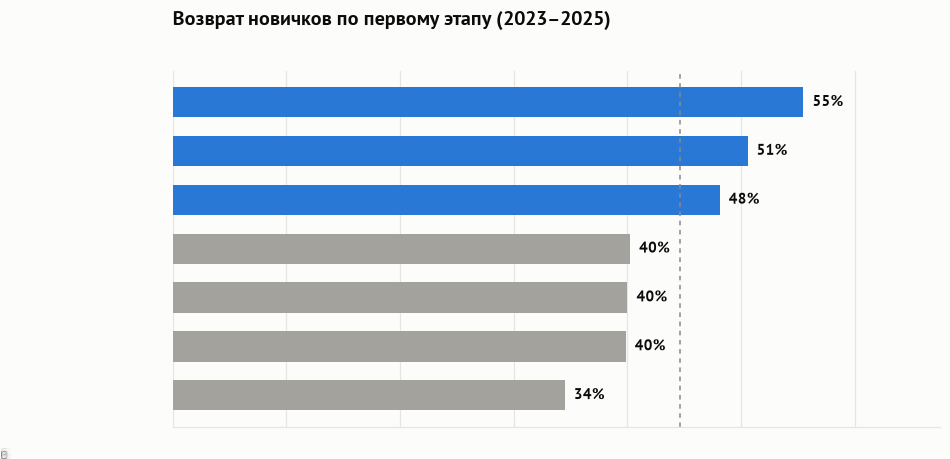

,mean,size
event_name,,
Спортмарафон Фест,0.345,345
SHULZ Gravel Weekend,0.398,261
Gravel Instinct,0.400,105
Моддер / Ардор,0.402,87
Fury Road,0.481,212
Царь Грейдер,0.506,265
Покрова,0.555,301


In [11]:
entry = newbies[newbies.fy >= 2023].merge(q("SELECT event_id, event_name FROM dim_event"),
                                          left_on="first_event", right_on="event_id")
e = (entry.groupby("event_name")["returned"].agg(["mean", "size"])
     .query("size >= 40").sort_values("mean"))

fig, ax = plt.subplots(figsize=(9, 4.2))
avg = entry.returned.mean()
colors = [BLUE if v >= avg else GRAY for v in e["mean"]]
ax.barh(e.index, e["mean"], color=colors, height=0.62)
ax.axvline(avg, color=TEXT_3, lw=1, ls=(0, (3, 3)))
for i, (v, n) in enumerate(zip(e["mean"], e["size"])):
    ax.text(v + 0.008, i, f"{v:.0%}  ", va="center", weight="bold", fontsize=10)
    ax.text(v + 0.055, i, f"n={n}", va="center", color=TEXT_3, fontsize=8.5)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlim(0, e["mean"].max() + 0.12)
ax.set_title("Возврат новичков по первому этапу (2023–2025)")
viz.subtitle(ax, f"Доля вернувшихся на следующий сезон; пунктир — среднее {avg:.0%}")
viz.save(fig, "04_entry_points"); plt.show()
e.round(3)

**Вывод:** разброс между этапами — 21 п.п. Лучшие «точки входа» — **Покрова (55%)** и **Царь Грейдер (51%)**.
Хуже всех удерживает **Спортмарафон Фест (34%)**: это фестиваль массового бренда с короткими дистанциями 40/65 км, и он привлекает разовых участников, а не гревел-аудиторию.
Причины на этих данных не установить, это гипотезы для проверки: формат (фестиваль или гонка), доля коротких дистанций, коммуникация после гонки.

## 6. Экосистема: как пересекаются аудитории этапов (2026)

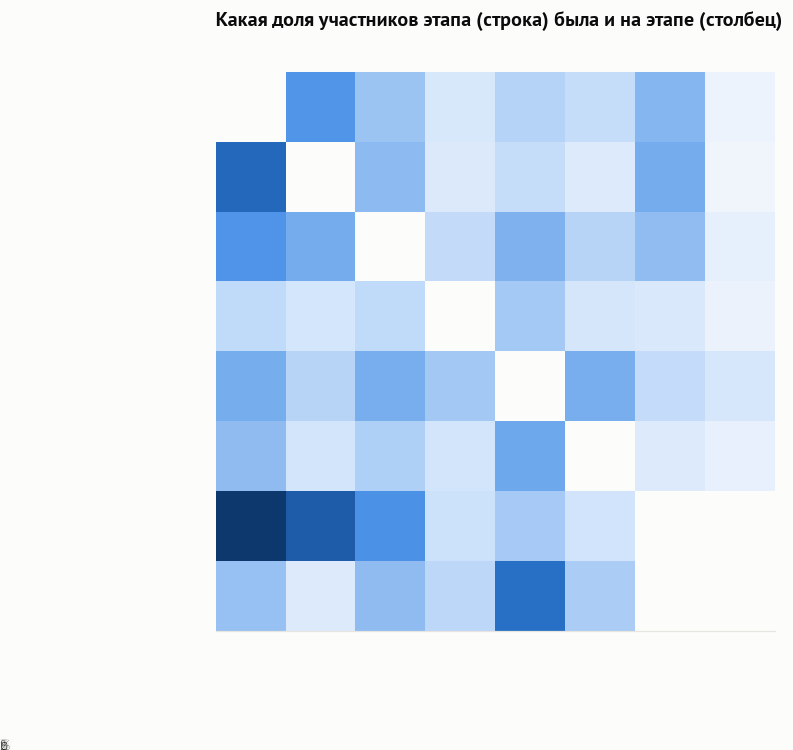

In [12]:
ov = q("SELECT event_a, event_b, share_of_a FROM mart_event_overlap WHERE year = 2026")
sizes26 = q('''SELECT e.event_name, COUNT(DISTINCT r.rider_id) n FROM fct_result r
               JOIN dim_event e ON e.event_id = r.event_id WHERE r.year = 2026 AND r.status <> 'dns' GROUP BY 1''')
order = sizes26.sort_values("n", ascending=False)["event_name"].tolist()
mat = ov.pivot(index="event_a", columns="event_b", values="share_of_a").reindex(index=order, columns=order)

fig, ax = plt.subplots(figsize=(8.6, 6.6))
ax.imshow(mat.values, cmap=viz.BLUES, vmin=0, vmax=0.65)
for i in range(len(order)):
    for j in range(len(order)):
        v = mat.values[i, j]
        if i == j:
            ax.text(j, i, "—", ha="center", va="center", color=TEXT_3)
        elif not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=9,
                    color="white" if v > 0.35 else TEXT)
n = sizes26.set_index("event_name")["n"]
ax.set_yticks(range(len(order)), [f"{o}  ({n[o]})" for o in order])
ax.set_xticks(range(len(order)), order, rotation=35, ha="right")
ax.grid(False)
ax.set_title("Какая доля участников этапа (строка) была и на этапе (столбец)")
viz.subtitle(ax, "Сезон 2026. В скобках — уникальные участники этапа")
viz.save(fig, "05_overlap"); plt.show()

**Выводы:**
- Есть плотное **ядро**: Моддер/Ардор, Fury Road и SHULZ. **64%** участников Ардора в том же сезоне ехали Fury Road, 51% — SHULZ.
  Это одна и та же аудитория, которая ездит «по кругу».
- Аудитории «Покровы» (Владимир) и Gravel Instinct пересекаются между собой, но слабее связаны с ядром. Это вторая точка притяжения.
- Fury Road — крупнейший этап (641 человек), но лишь 23% его участников были на Ардоре. **Большой этап — главный «вход» в серию**, его аудиторию стоит целенаправленно вести на другие этапы.

## 7. Прогрессия: переходят ли с короткой дистанции на длинную

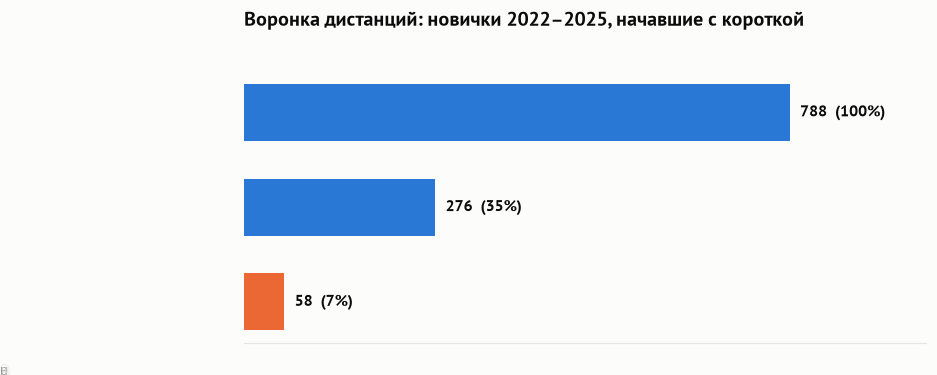

Первый сезон — только короткая    788
Вернулись в следующем сезоне      276
...и проехали длинную              58
dtype: int64

In [13]:
# окно наблюдения одинаковое для всех когорт: первый сезон + следующий
path = q("SELECT * FROM mart_distance_path WHERE first_year BETWEEN 2022 AND 2025")
short = path[~path.first_season_long]
funnel = pd.Series({
    "Первый сезон — только короткая": len(short),
    "Вернулись в следующем сезоне": int(short.returned_next.sum()),
    "...и проехали длинную": int(short.long_next.sum()),
})
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(funnel.index[::-1], funnel.values[::-1], color=[BLUE, BLUE, ORANGE][::-1], height=0.6)
for i, v in enumerate(funnel.values[::-1]):
    ax.text(v + 15, i, f"{v}  ({v / funnel.iloc[0]:.0%})", va="center", weight="bold")
ax.grid(axis="y", visible=False); ax.set_xlim(0, funnel.max() * 1.25)
ax.set_title("Воронка дистанций: новички 2022–2025, начавшие с короткой")
viz.subtitle(ax, "Окно: первый сезон + следующий. Из вернувшихся на длинную выходит лишь каждый пятый")
viz.save(fig, "06_distance_funnel"); plt.show()
funnel

**Вывод:** из начавших с короткой на следующий сезон возвращаются **35%** (у начавших с длинной — 50%), и из вернувшихся
на длинную выходит только **21%**. Короткая дистанция — **отдельный продукт со своей аудиторией**, а не ступенька к главной.
Её удержание нужно растить отдельно, а не рассчитывать, что люди «дорастут» до длинной.

> **Методическая заметка.** Первая версия этой воронки считала переход за всё время наблюдения и давала 53%. Это завышение:
> у когорты 2022 года было четыре сезона на переход, у когорты 2025-го — один. При одинаковом окне получается 21%.

## 8. Аудитория: женщин стало в 2,5 раза больше

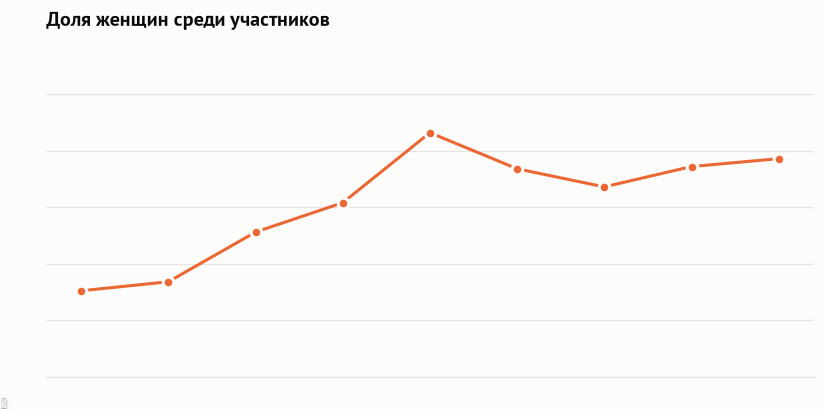

In [14]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(season.year, season.female_share, color=ORANGE, marker="o", ms=7, mec=SURFACE, mew=2)
for x, v in zip(season.year, season.female_share):
    ax.text(x, v + 0.012, f"{v:.0%}", ha="center", fontsize=9.5, color=TEXT)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_ylim(0, 0.27); ax.set_xticks(season.year)
ax.set_title("Доля женщин среди участников")
viz.subtitle(ax, "Рост с 8% до ~19%, с 2022 года плато.")
viz.save(fig, "07_female_share"); plt.show()

Доля женщин выросла с 8% до 17–22% и с 2022 года держится на плато. Сырой retention у женщин ниже (37% против 45%), но после контроля дистанции разница незначима (раздел 4).
Значит, задача — не «удержать женщин», а **снова запустить привлечение**: отдельные зачёты, призы и женские группы на коротких дистанциях.

## 9. Трассы: скорость и сходы (2026)

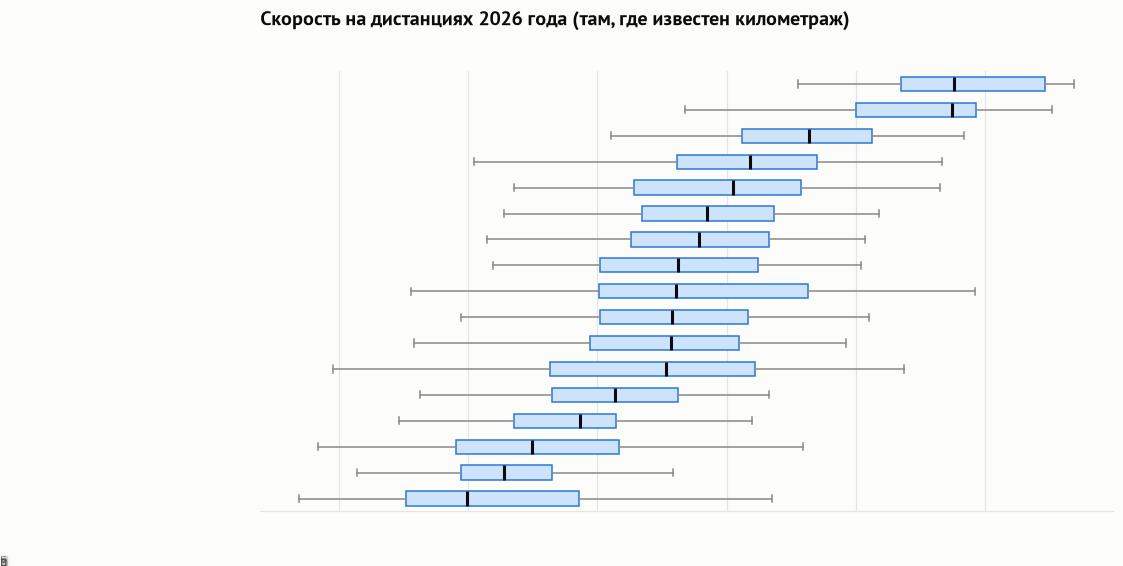

In [15]:
sp = q('''
SELECT e.event_name || ' · ' || d.race_title AS race, d.distance_km, r.speed_kmh, r.gender
FROM fct_result r JOIN dim_race d ON d.race_id = r.race_id JOIN dim_event e ON e.event_id = r.event_id
WHERE r.year = 2026 AND r.status = 'finished' AND r.speed_kmh IS NOT NULL AND d.bike_class = 'multi'
''')
order = sp.groupby("race")["speed_kmh"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 5.2))
data = [sp.loc[sp.race == r, "speed_kmh"] for r in order]
bp = ax.boxplot(data, orientation="horizontal", widths=0.55, patch_artist=True, showfliers=False,
                medianprops=dict(color=TEXT, lw=2), whiskerprops=dict(color=TEXT_3),
                capprops=dict(color=TEXT_3), boxprops=dict(facecolor="#cde2fb", edgecolor=BLUE))
ax.set_yticks(range(1, len(order) + 1), order, fontsize=9)
for i, d in enumerate(data, 1):
    ax.text(d.median(), i + 0.38, f"{d.median():.1f}", ha="center", fontsize=8, color=TEXT_2)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("средняя скорость финишёра, км/ч")
ax.set_title("Скорость на дистанциях 2026 года (там, где известен километраж)")
viz.subtitle(ax, "Медиана и межквартильный размах. Царь Грейдер — почти шоссе: медиана 34 км/ч на 180 км")
viz.save(fig, "08_speed"); plt.show()

In [16]:
q('''SELECT event_name, year, race_title, starters, dnf, dnf_rate, dns_rate
     FROM mart_dnf WHERE year >= 2025 ORDER BY dnf_rate DESC''')

,event_name,year,race_title,starters,dnf,dnf_rate,dns_rate
0,Спортмарафон Фест,2026,BIKE 125 GRAVEL,75,24,0.320,0.107
1,Gravel Instinct,2026,ГЛУХАРЬ 170 км,24,5,0.208,0.040
2,Gravel Instinct,2026,ИССЛЕДОВАТЕЛЬ,15,3,0.200,0.000
3,Спортмарафон Фест,2025,BIKE 125 GRAVEL,58,7,0.121,0.079
4,Покрова,2026,Мультиспид и синглспид,310,32,0.103,0.072
5,Gravel Instinct,2026,СТРИЖ 170 км,148,15,0.101,0.075
6,Спортмарафон Фест,2025,BIKE 65 GRAVEL,77,7,0.091,0.144
7,Покрова,2026,Фикс,16,1,0.063,0.000
8,Gravel Instinct,2026,КОЛИБРИ 88 км,166,8,0.048,0.035
9,Спортмарафон Фест,2026,BIKE 65 GRAVEL,95,4,0.042,0.050


Сход и неявка фиксируются не во всех протоколах (только у части организаторов), поэтому сравниваю внутри доступных:
- Самый высокий сход — **BIKE 125 на Спортмарафон Фест 2026 (32%)**, втрое выше прошлогоднего (12%). Вероятно, погода или трасса, стоит разобрать с организатором.
- **Неявка (DNS) на короткие дистанции фестиваля — 23–27%.** Это потерянные слоты и деньги: напоминания перед стартом, лист ожидания.

## 10. Итоги

| # | Инсайт | Что делать |
|---|---|---|
| 1 | Аудитория выросла в 12 раз (145 → 1 814), частота — с 1,0 до 1,5 старта на гонщика | Серия работает, растить календарь |
| 2 | После обвала 2022 года (7%) retention +1 сезона восстановился до 45–51%, выше эпохи одной гонки | Мониторить: у когорты 2025 года просадка на 6 п.п. |
| 3 | **Второй старт в первом сезоне: шансы вернуться ×2,7** (устойчиво к поправке на этап) | Проверить A/B-тестом промокода на второй этап: ~850 новичков за сезон дают MDE ≈ 9 п.п. |
| 4 | Короткая удерживает 35% против 50% у длинной; на длинную за сезон переходит лишь 21% вернувшихся | Растить удержание короткой как отдельного продукта |
| 5 | Ядро аудитории — 3 этапа с пересечением 47–64%; лучшие «входы» — Покрова и Царь Грейдер (51–55% возврата), худший — Спортмарафон (34%) | Вести аудиторию крупнейшего этапа (Fury Road) на остальные; разобрать практики лидеров |
| 6 | Доля женщин на плато ~19% | Отдельные зачёты и коммьюнити, затем замер эффекта |

**Ограничения:** гонщики сведены по имени (тёзки ~0.3%); DNF/DNS есть не во всех протоколах; километраж известен для части дистанций;
в данных нет возраста, региона и цены слота, поэтому рекомендации — гипотезы для A/B-проверки, а не доказанная причинность.